#### Perform Following operations on dataset - California housing dataset
##### data preprocessing(info, describe)
##### data cleaning (null values, duplicates)
##### data manipulation (rename column, mapping data of string column with 0,1,2,3,4)
##### data visualization(heatmap, scatter plot, line plot, histogram)
##### splitting(x-axis and y-axis)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
data=pd.read_csv(r"C:\Users\ANSHU\Desktop\AIMLTraining\Assignment\Dataset\california_housing_dataset.csv")

In [4]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


Data Preprocessing (info, describe)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


In [6]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Data Cleaning (null/duplicate values)

In [7]:
data.isnull().sum()                 # 207 NULL values in total_bedroom column

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

In [8]:
data.duplicated().sum()             # No Duplicate Values

np.int64(0)

In [9]:
data[data['total_bedrooms'].isnull()].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,207.000000,207.000000,207.000000,207.000000,0.0,207.000000,207.000000,207.000000,207.000000
mean,-119.472560,35.497633,29.270531,2562.603865,NaN,1477.772947,510.024155,3.822244,206007.280193
std,2.001424,2.097298,11.964927,1787.269789,NaN,1057.448212,386.120704,1.955595,111638.214545
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.810000,33.970000,19.000000,1307.500000,NaN,781.000000,258.000000,2.564150,128750.000000
50%,-118.490000,34.200000,30.000000,2155.000000,NaN,1217.000000,427.000000,3.411500,175000.000000
75%,-117.985000,37.495000,38.000000,3465.000000,NaN,1889.500000,628.000000,4.615750,267700.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


In [10]:
data[data['total_bedrooms'].isnull()].mean(numeric_only=True)

longitude               -119.472560
latitude                  35.497633
housing_median_age        29.270531
total_rooms             2562.603865
total_bedrooms                  NaN
population              1477.772947
households               510.024155
median_income              3.822244
median_house_value    206007.280193
dtype: float64

In [11]:
data['total_bedrooms']=(data.groupby('ocean_proximity')['total_bedrooms'].transform((lambda x:x.fillna(x.median()))))

In [12]:
data.isnull().sum()                 #All NULL values filled using groupby

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

Data Manipulation - Renaming Column and mapping data of string column with 0,1,2,3,4

In [13]:
data.rename(columns={"median_house_value":"house_value"},inplace=True)

In [14]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,INLAND,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,INLAND,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,INLAND,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,INLAND,84700


In [15]:
data['ocean_proximity'].value_counts()              #unique_values

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [16]:
mapping={
    'NEAR BAY':0,
    '<1H OCEAN':1,
    'INLAND':2,
    'NEAR OCEAN':3,
    'ISLAND':4
}
data['ocean_proximity']=data['ocean_proximity'].map(mapping)

In [17]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,0,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,0,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,0,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,0,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,0,342200
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,2,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,2,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,2,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,2,84700


In [18]:
data.to_csv(r"C:\Users\ANSHU\Desktop\AIMLTraining\Assignment\CleanedDataset\california_housing_dataset_cleaned.csv")

### Data Visualization

#### Univariate Analysis

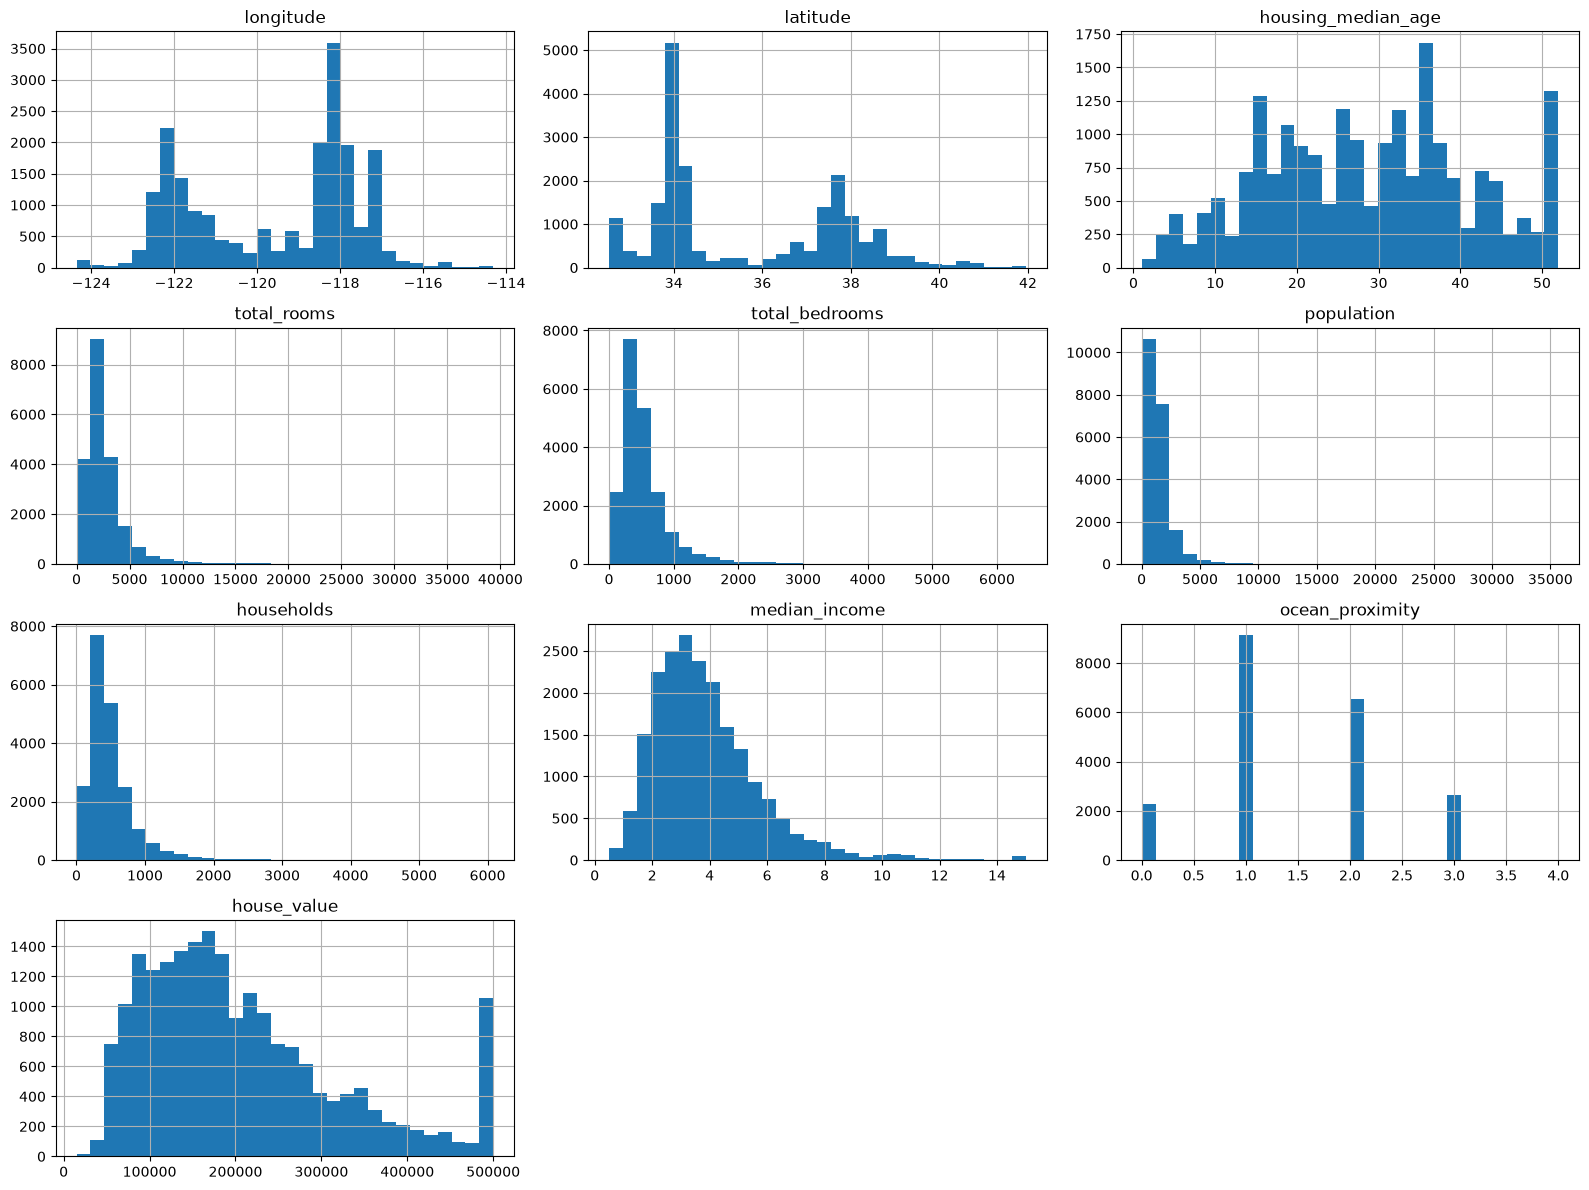

In [19]:
data.hist(figsize=(16,12),bins=30)
plt.tight_layout()
plt.show()

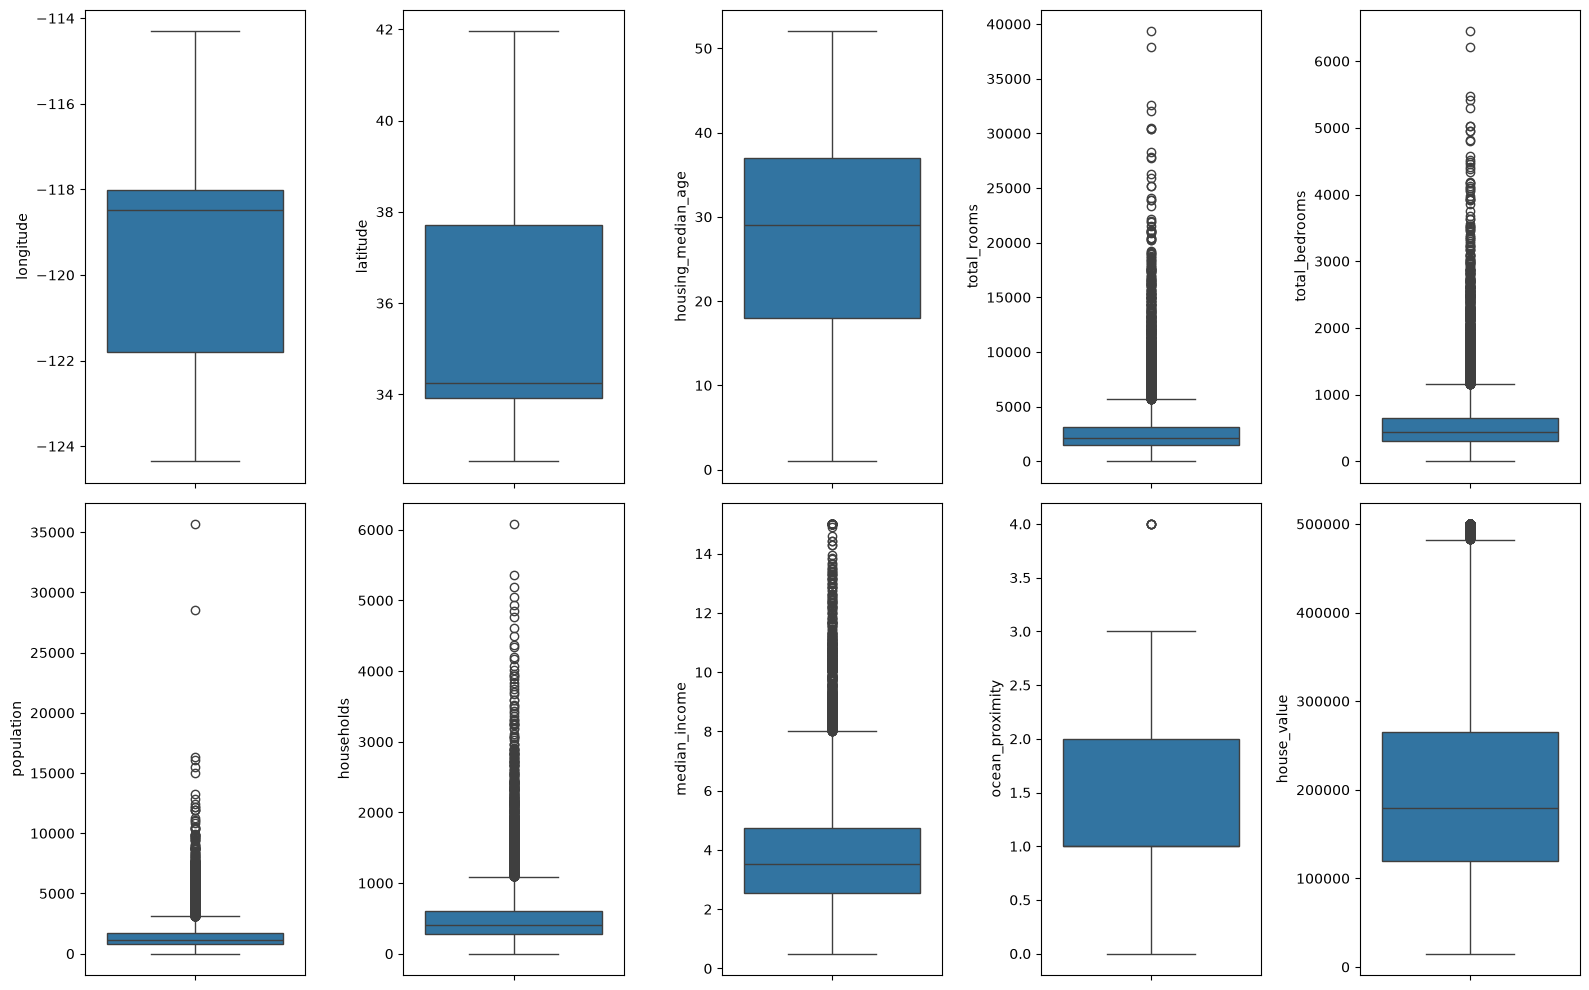

In [20]:
plt.figure(figsize=(16,10))
for i,col in enumerate(data.columns,1):
    plt.subplot(2,5,i)
    sns.boxplot(y=data[col])
plt.tight_layout()
plt.show()

#### Bivariate Analysis

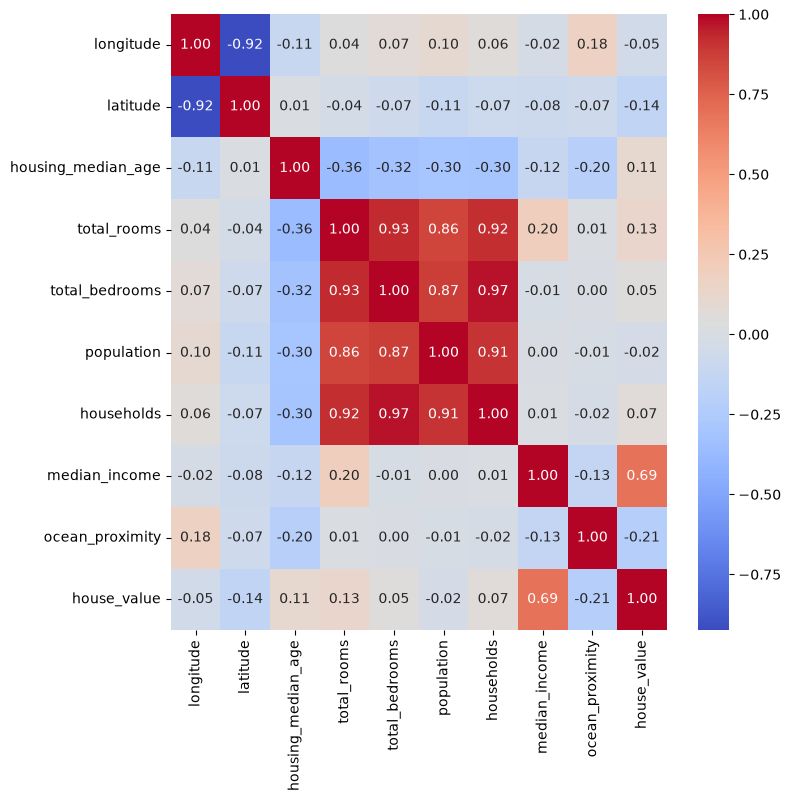

In [21]:
plt.figure(figsize=(8,8))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

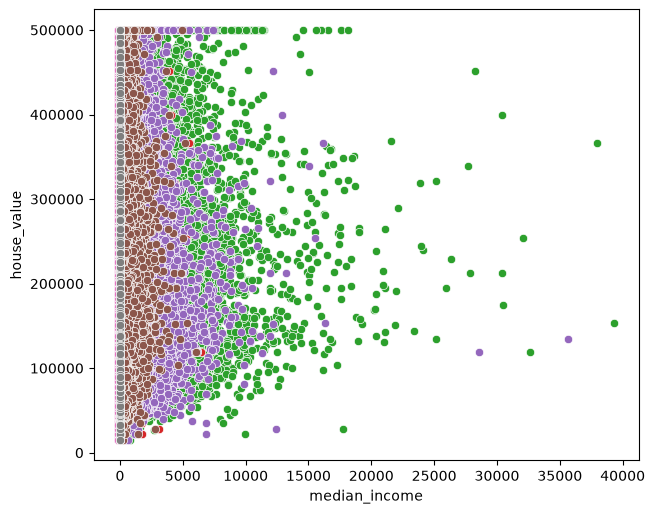

In [22]:
# Scatterplot with Target Value
features=["median_income","housing_median_age","total_rooms","total_bedrooms","population","households","longitude","latitude"]
plt.figure(figsize=(18,15))
for i,col in enumerate(features,1):
    plt.subplot(3,3,1)
    sns.scatterplot(x=data[col],y=data['house_value'])
plt.tight_layout()
plt.show()


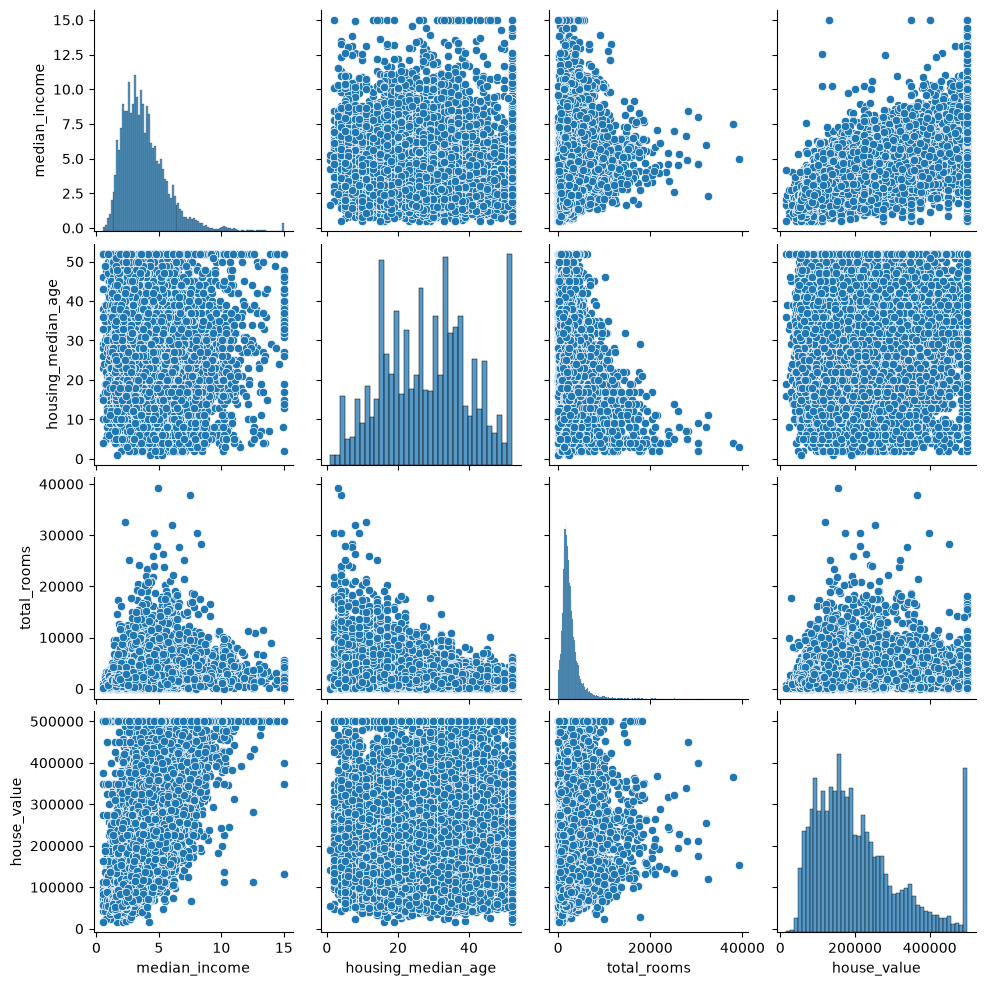

In [23]:
# Pair Plot
sns.pairplot(data[['median_income','housing_median_age','total_rooms','house_value']])

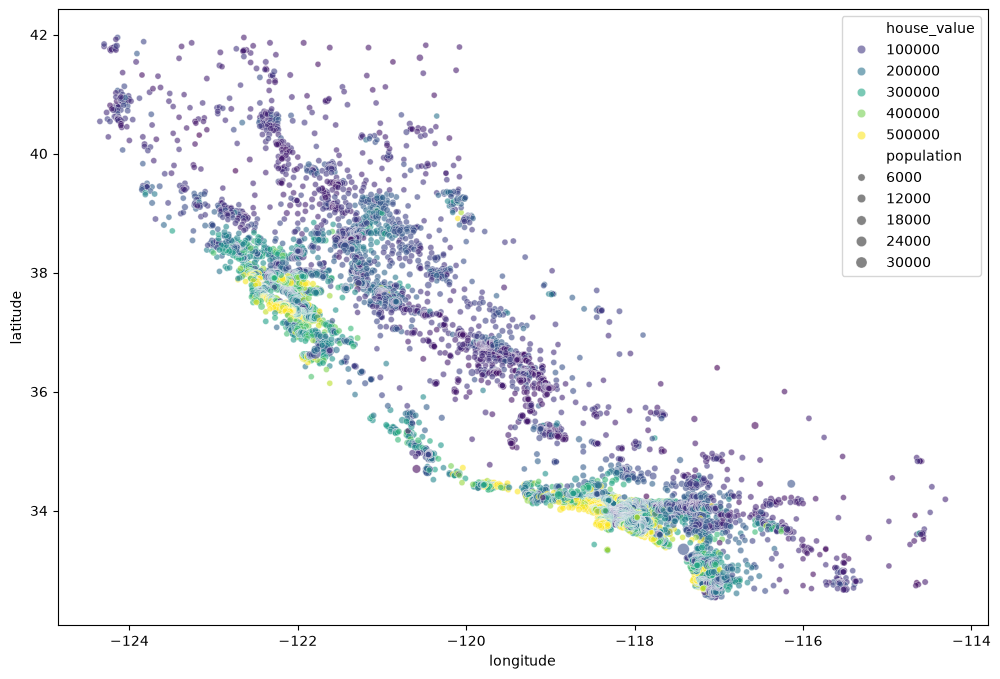

In [24]:
# Scatterplot with Multiple Variables
plt.figure(figsize=(12,8))
sns.scatterplot(data=data,x='longitude',y='latitude',size='population',hue='house_value',palette='viridis',alpha=0.6)
plt.show()

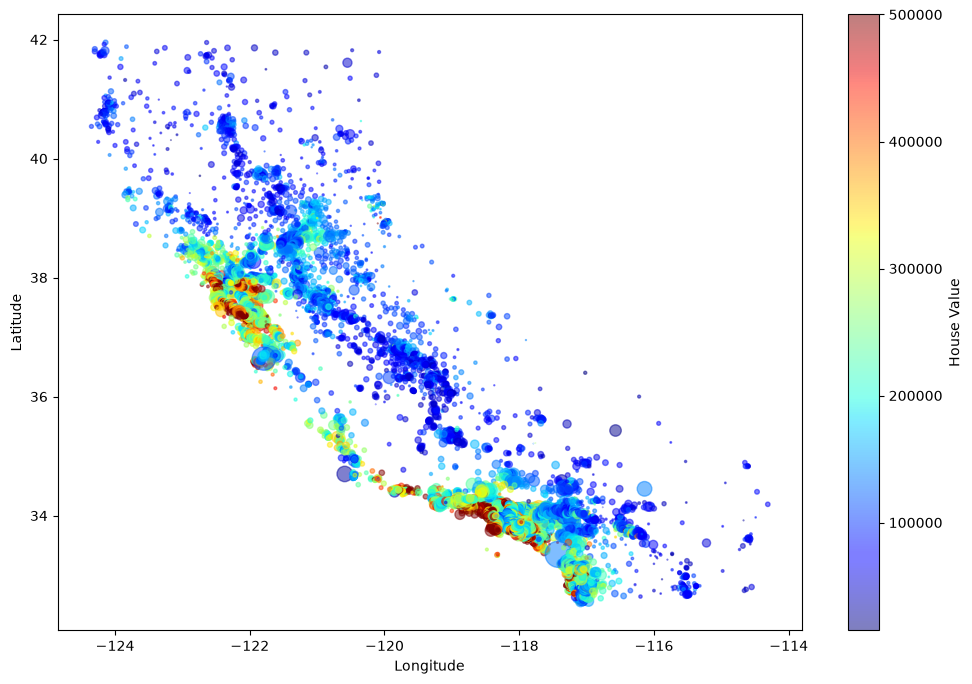

In [25]:
# Bubble Plot
plt.figure(figsize=(12,8))
plt.scatter(data['longitude'],data['latitude'],s=data['population']/100,c=data['house_value'],cmap='jet',alpha=0.5)
plt.colorbar(label='House Value')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


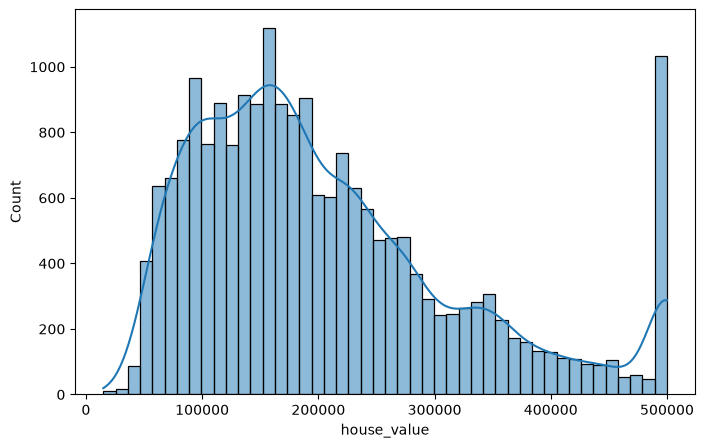

In [26]:
# Distribution of target variable
plt.figure(figsize=(8,5))
sns.histplot(data['house_value'],kde=True)
plt.show()


In [27]:
# Feature vs Target Correlation
corr = data.corr()['house_value'].sort_values(ascending=False)
print(corr)


house_value           1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049580
population           -0.024650
longitude            -0.045967
latitude             -0.144160
ocean_proximity      -0.210600
Name: house_value, dtype: float64


In [28]:
# Splitting
X = data.drop('house_value', axis=1)
y = data['house_value']
print(X.shape)
print(y.shape)



(20640, 9)
(20640,)


In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 9)
(4128, 9)
(16512,)
(4128,)


In [30]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-41832.1 ,-41881.01, 1146.88,..., 45.89, 40300.31, -3151.31]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.496e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [31]:
y_pred=model.predict(X_test)

In [32]:
y_pred

array([ 61781.06978386, 151515.75515358, 254871.70931262, ...,
       438928.14169585, 129292.4078811 , 177122.75454932], shape=(4128,))

In [33]:
m=model.coef_
c=model.intercept_

In [34]:
print(m)
print(c)

[-4.18320996e+04 -4.18810051e+04  1.14688053e+03 -7.81906802e+00
  1.14970518e+02 -3.87074575e+01  4.58943439e+01  4.03003126e+04
 -3.15130900e+03]
-3496010.4626618423


In [36]:
y=(-122.24*m[0]+37.85*m[1]+52*m[2]+1467*m[3]+190.0*m[4]+496*m[5]+177*m[6]+7.2574*m[7]+0*m[8])+c
print(y)

383760.8529759431


In [37]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

5055306807.678968
0.6142191566433527
51794.68855215173
